In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
class ESN:
    def __init__(self, n_inputs, n_outputs, n_reservoir = 100, spectral_radius = 0.95, sparsity = 0.1, random_state = None):
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.n_reservoir = n_reservoir
        self.spectral_radius = spectral_radius
        self.sparsity = sparsity
        self.random_state = np.random.RandomState(random_state)
        self.win = self.random_state.rand(self.n_reservoir, self.n_reservoir) - 0.5
        
W = self.random_state.rand(self.n_reservoir, self.n_reservoir) - 0.5  

        
        

In [12]:


# reproducibility
np.random.seed(42)

# generate sine wave
t = np.arrange(0, 100, 0.1)
data = np.sin(t)

plt.plot(t, data)
plt.title("Sine Wave")
plt.show()

AttributeError: module 'numpy' has no attribute 'arrange'

In [5]:
def create_dataset(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20
X, y = create_dataset(data, window_size)

# reshape for LSTM: [samples, timesteps, features]
X_lstm = X.reshape((X.shape[0], X.shape[1], 1))

# train-test split
split = int(0.8 * len(X))
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y[:split], y[split:]

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)



Epoch 1/20

25/25 [==============================] - 3s 30ms/step - loss: 0.2351 - val_loss: 0.1024
Epoch 2/20
25/25 [==============================] - 0s 9ms/step - loss: 0.0387 - val_loss: 0.0046
Epoch 3/20
25/25 [==============================] - 0s 9ms/step - loss: 0.0024 - val_loss: 6.9297e-04
Epoch 4/20
25/25 [==============================] - 0s 9ms/step - loss: 2.8762e-04 - val_loss: 1.7083e-04
Epoch 5/20
25/25 [==============================] - 0s 9ms/step - loss: 1.5632e-04 - val_loss: 1.1739e-04
Epoch 6/20
25/25 [==============================] - 0s 9ms/step - loss: 1.0695e-04 - val_loss: 9.2320e-05
Epoch 7/20
25/25 [==============================] - 0s 11ms/step - loss: 8.3955e-05 - val_loss: 7.2165e-05
Epoch 8/20
25/25 [==============================] - 0s 9ms/step - loss: 6.0935e-05 - val_loss: 5.4118e-05
Epoch 9/20
25/25 [==============================] - 0s 11ms/step - loss: 4.7132e-05 - val_loss: 3.6330e-05
Epoch 10/20
25/25 [==============================] - 0s 9ms/

7/7 [==============================] - 1s 3ms/step


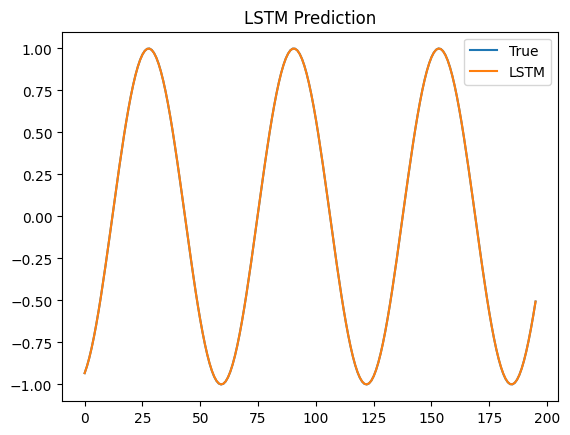

In [7]:
y_pred_lstm = model.predict(X_test)

plt.plot(y_test, label="True")
plt.plot(y_pred_lstm, label="LSTM")
plt.legend()
plt.title("LSTM Prediction")
plt.show()

In [8]:
class ESN:
    def __init__(self, input_dim, reservoir_size=200, spectral_radius=0.9, sparsity=0.1):
        self.input_dim = input_dim
        self.reservoir_size = reservoir_size
        
        # input weights
        self.Win = np.random.uniform(-1, 1, (reservoir_size, input_dim))
        
        # reservoir weights
        W = np.random.rand(reservoir_size, reservoir_size) - 0.5
        
        # sparsity
        mask = np.random.rand(*W.shape) < sparsity
        W[mask] = 0
        
        # normalize spectral radius
        eigvals = np.linalg.eigvals(W)
        W *= spectral_radius / np.max(np.abs(eigvals))
        
        self.W = W
        self.state = np.zeros(reservoir_size)

    def update(self, u):
        self.state = np.tanh(
            np.dot(self.Win, u) + np.dot(self.W, self.state)
        )
        return self.state

In [9]:
def train_esn(esn, X, y):
    states = []
    
    for i in range(len(X)):
        esn.state = np.zeros(esn.reservoir_size)
        for t in X[i]:
            state = esn.update([t])
        states.append(state)
    
    states = np.array(states)
    
    # linear regression for output weights
    Wout = np.linalg.pinv(states) @ y
    return Wout

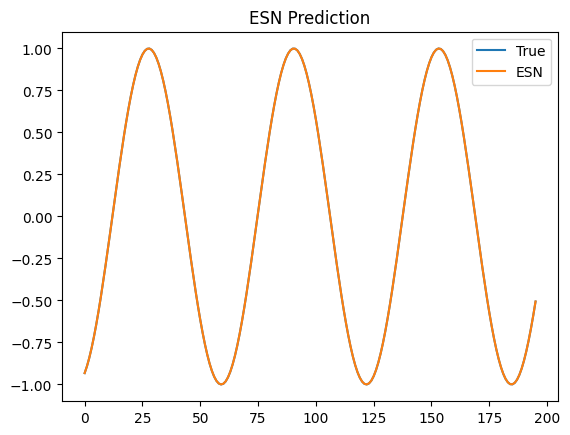

In [10]:
def predict_esn(esn, Wout, X):
    preds = []
    
    for i in range(len(X)):
        esn.state = np.zeros(esn.reservoir_size)
        for t in X[i]:
            state = esn.update([t])
        preds.append(state @ Wout)
    
    return np.array(preds)

# reshape X for ESN (no 3D needed)
X_esn = X

X_train_esn, X_test_esn = X_esn[:split], X_esn[split:]

esn = ESN(input_dim=1)

Wout = train_esn(esn, X_train_esn, y_train)
y_pred_esn = predict_esn(esn, Wout, X_test_esn)

plt.plot(y_test, label="True")
plt.plot(y_pred_esn, label="ESN")
plt.legend()
plt.title("ESN Prediction")
plt.show()

In [11]:
from sklearn.metrics import mean_squared_error

mse_lstm = mean_squared_error(y_test, y_pred_lstm)
mse_esn = mean_squared_error(y_test, y_pred_esn)

print("LSTM MSE:", mse_lstm)
print("ESN MSE:", mse_esn)

LSTM MSE: 4.539581008636242e-07
ESN MSE: 6.463929119680824e-08
